## **Part 1 - Cleaning**

#### **Import packages**

In [44]:
import numpy as np
import pandas as pd

---

#### **Load orders table**

In [ ]:
# Dont forget to change the path same goes for all loads
orderdf = pd.read_csv("D:/Downloads/Team Project/0_Data/olist_orders_dataset.csv")

##### Check the null values

In [46]:
orderdf.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

##### Drop null values

In [47]:
# Maybe we have null dates because the orders were are still in process in the time we extracted the data

# Either ways we are going to remove the rows that contain null value in this case
orderdf.dropna(inplace=True)

##### Convert date columns to datetime

In [48]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orderdf[col] = pd.to_datetime(orderdf[col], errors='coerce')

##### Check again


In [49]:
orderdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96461 non-null  object        
 1   customer_id                    96461 non-null  object        
 2   order_status                   96461 non-null  object        
 3   order_purchase_timestamp       96461 non-null  datetime64[ns]
 4   order_approved_at              96461 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96461 non-null  datetime64[ns]
 6   order_delivered_customer_date  96461 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96461 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.6+ MB


---

#### **Load products table**

In [50]:
productdf = pd.read_csv("D:/Downloads/Team Project/0_Data/olist_products_dataset.csv")

##### Check table

In [51]:
productdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


##### Check null values 

In [52]:
productdf.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

##### Drop NA values in category name

In [53]:
# Since we only care about category name we are going to remove any row that have no category name
productdf.dropna(subset=["product_category_name"],inplace=True)

##### Translate Category names table

In [54]:
# Load the translation table
translatondf = pd.read_csv("D:/Downloads/Team Project/0_Data/product_category_name_translation.csv")

# Merge Both Tables
productdf = pd.merge(productdf, translatondf, on='product_category_name', how='left')

# Replace columns (we add fillna in case if the cell ran again so it wont destruct the data)
productdf['product_category_name'] = productdf['product_category_name_english'].fillna(productdf['product_category_name'])

# Drop product_category_name_english column
productdf.drop(columns=["product_category_name_english"],inplace=True)

##### Alter category name column

In [55]:
# Handle missing translations
productdf['product_category_name'] = productdf['product_category_name'].fillna('other')

# Alter the column
productdf["product_category_name"] = productdf["product_category_name"].str.replace("_"," ").str.title()

##### Check the unique categorys

In [56]:
productdf["product_category_name"].unique()

array(['Perfumery', 'Art', 'Sports Leisure', 'Baby', 'Housewares',
       'Musical Instruments', 'Cool Stuff', 'Furniture Decor',
       'Home Appliances', 'Toys', 'Bed Bath Table',
       'Construction Tools Safety', 'Computers Accessories',
       'Health Beauty', 'Luggage Accessories', 'Garden Tools',
       'Office Furniture', 'Auto', 'Electronics', 'Fashion Shoes',
       'Telephony', 'Stationery', 'Fashion Bags Accessories', 'Computers',
       'Home Construction', 'Watches Gifts',
       'Construction Tools Construction', 'Pet Shop', 'Small Appliances',
       'Agro Industry And Commerce', 'Furniture Living Room',
       'Signaling And Security', 'Air Conditioning', 'Consoles Games',
       'Books General Interest', 'Costruction Tools Tools',
       'Fashion Underwear Beach', 'Fashion Male Clothing',
       'Kitchen Dining Laundry Garden Furniture',
       'Industry Commerce And Business', 'Fixed Telephony',
       'Construction Tools Lights', 'Books Technical',
       'Home App

---

#### **Load order items table**

In [57]:
itemsdf = pd.read_csv("D:/Downloads/Team Project/0_Data/olist_order_items_dataset.csv")

##### Check table 

In [58]:
itemsdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


##### Convert shipping limit date column to datetime data type

In [59]:
itemsdf["shipping_limit_date"] = pd.to_datetime(itemsdf["shipping_limit_date"])

##### Check null values

In [60]:
itemsdf.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

---

#### **Load customers table**

In [61]:
customersdf = pd.read_csv("D:/Downloads/Team Project/0_Data/olist_customers_dataset.csv")

##### Check table 

In [62]:
customersdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


##### Check null values

In [63]:
customersdf.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

##### Set city column as title

In [64]:
customersdf["customer_city"] = customersdf["customer_city"].str.title()

---

#### **Load sellers table**

In [65]:
sellersdf = pd.read_csv("D:/Downloads/Team Project/0_Data/olist_sellers_dataset.csv")

##### Check table

In [66]:
sellersdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


##### Check null values

In [67]:
sellersdf.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

##### Set city column as title

In [68]:
sellersdf["seller_city"] = sellersdf["seller_city"].str.title()

---

## **Part 2 - Feature Engineering**

##### Create processing time column

In [69]:
orderdf["processing_time"] = (orderdf["order_approved_at"] - orderdf["order_purchase_timestamp"]).dt.days

##### Create seller to carrier days column

In [70]:
orderdf['seller_to_carrier_days'] = (
    orderdf['order_delivered_carrier_date'] - orderdf['order_approved_at']).dt.days

##### Create shipping_time column

In [71]:
orderdf['shipping_time'] = (
    orderdf['order_delivered_customer_date'] - orderdf['order_delivered_carrier_date']
).dt.days


##### Create delivery days column

In [72]:
orderdf['delivery_days'] = (
    orderdf['order_delivered_customer_date'] - orderdf['order_purchase_timestamp']
).dt.days

##### Create delivery delay days column

In [73]:
orderdf['delivery_delay_days'] = (
    orderdf['order_delivered_customer_date'] - orderdf['order_estimated_delivery_date']
).dt.days

##### Create delivery status column

In [74]:
orderdf['delivery_status'] = np.where(
    orderdf['order_delivered_customer_date'] <= orderdf['order_estimated_delivery_date'],
    'On Time / Early',
    'Late Delivery'
)

##### Reorder the columns

In [75]:
orderdf = orderdf[[
    # Order Info
    'order_id',
    'customer_id',
    'order_status',

    # Timeline (chronological)
    'order_purchase_timestamp',
    'order_approved_at',
    'processing_time',

    'order_delivered_carrier_date',
    'seller_to_carrier_days',
    'shipping_time',

    'order_delivered_customer_date',
    'delivery_days',

    'order_estimated_delivery_date',

    # Evaluation
    'delivery_delay_days',
    'delivery_status'
]]

---

## **Part 3 - Analysis**

In [76]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

#### Order Status Distribution

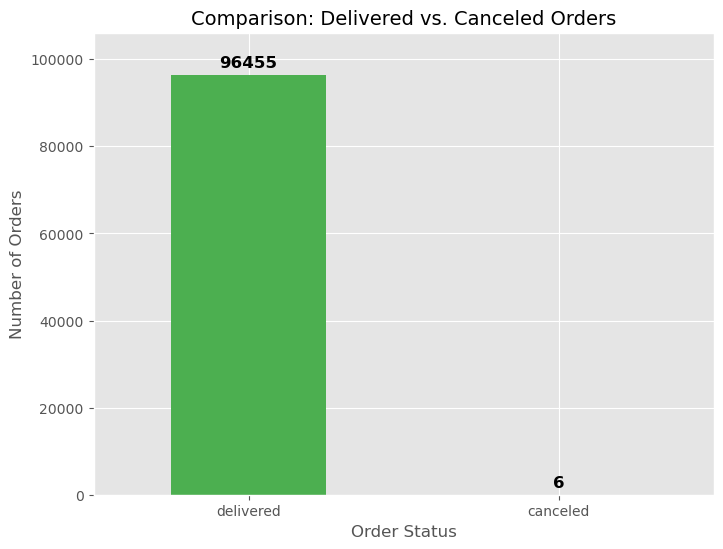

In [77]:
# Count how many orders fall into each status (delivered, canceled, etc.)
status_counts = orderdf['order_status'].value_counts()

# Plot distribution
plt.figure(figsize=(8, 6))
ax = status_counts.plot(kind='bar', color=['#4CAF50', '#F44336']) # Green for delivered, Red for canceled

# Add Data Labels (Counts) on top
ax.bar_label(ax.containers[0], padding=3, fontsize=12, fontweight='bold')

# Titles and Labels
plt.title('Comparison: Delivered vs. Canceled Orders', fontsize=14)
plt.xlabel('Order Status', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)

# Optional: Clean up the look
plt.xticks(rotation=0) # Keep labels horizontal since there are only two
plt.ylim(0, status_counts.max() * 1.1) # Add space for the labels

plt.show()

#### Orders Over Time (Demand Trend)

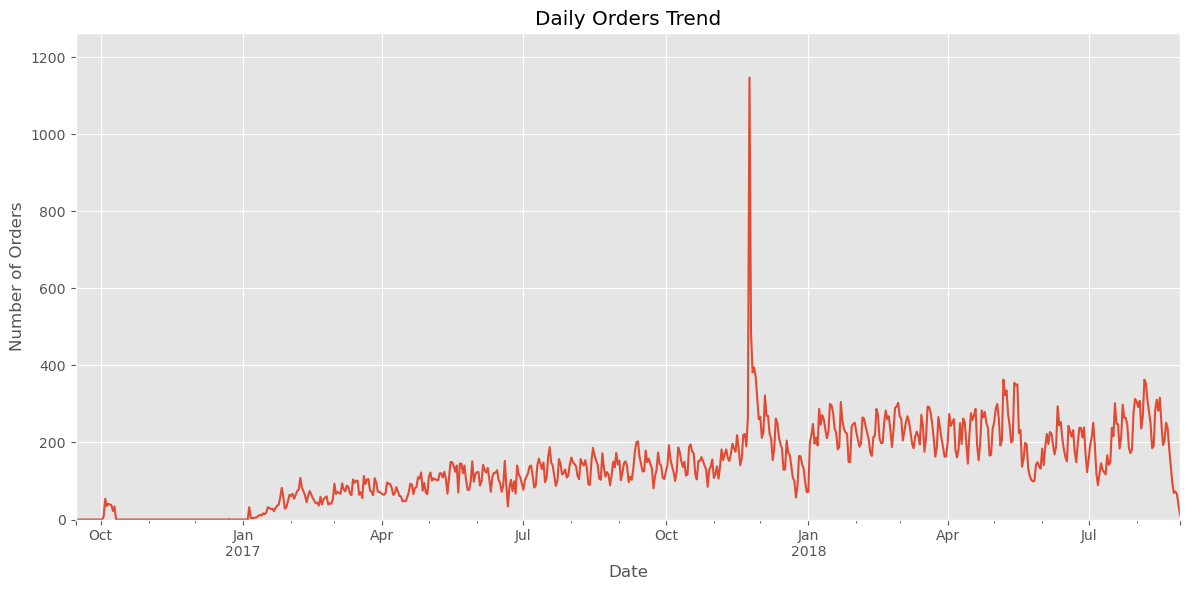

In [ ]:
# Aggregate number of orders per day
orders_per_day = orderdf.set_index('order_purchase_timestamp').resample('D').size()

# Plot time series
plt.figure()
orders_per_day.plot(figsize=(12, 6))

plt.title('Daily Orders Trend')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.ylim(0, orders_per_day.max() * 1.1)

plt.tight_layout()
plt.show()

#### Average Processing Time Over Time

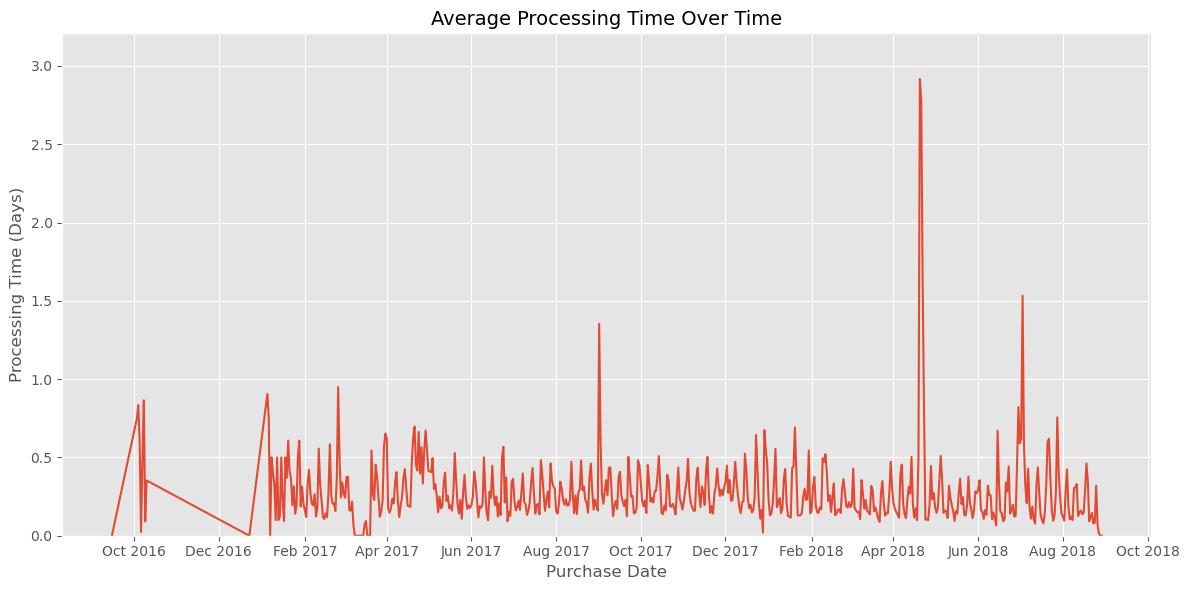

In [ ]:
import matplotlib.dates as mdates

# Group by date and compute mean
avg_processing = orderdf.groupby(orderdf['order_purchase_timestamp'].dt.date)['processing_time'].mean()

plt.figure(figsize=(12, 6))
ax = avg_processing.plot()

# Set the locator to show labels by month (or every 3 months)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2)) 

# Format the date
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.title('Average Processing Time Over Time', fontsize=14)
plt.xlabel('Purchase Date', fontsize=12)
plt.ylabel('Processing Time (Days)', fontsize=12)
plt.ylim(0, avg_processing.max() * 1.1)

plt.tight_layout()
plt.show()

#### Shipping Time Distribution

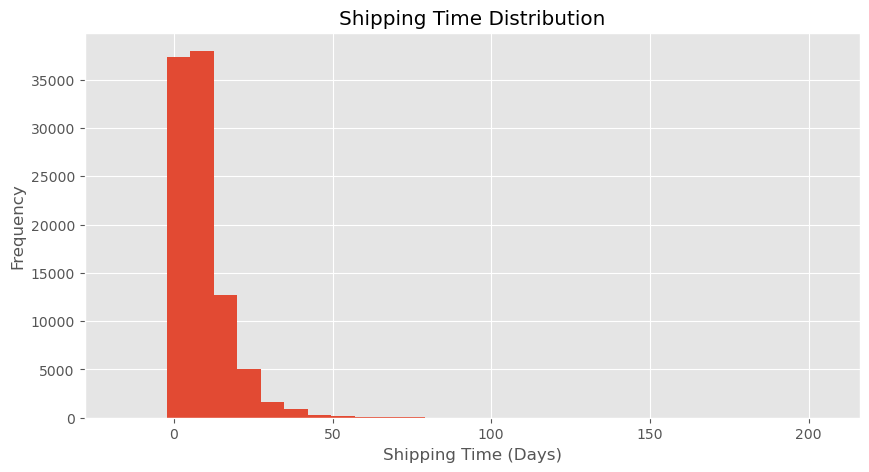

In [80]:
# Plot histogram of shipping time
plt.figure(figsize=(10, 5))
plt.hist(orderdf['shipping_time'].dropna(), bins=30)

plt.title('Shipping Time Distribution')
plt.xlabel('Shipping Time (Days)')
plt.ylabel('Frequency')

plt.show()

#### Delivery Delay Distribution + KPI

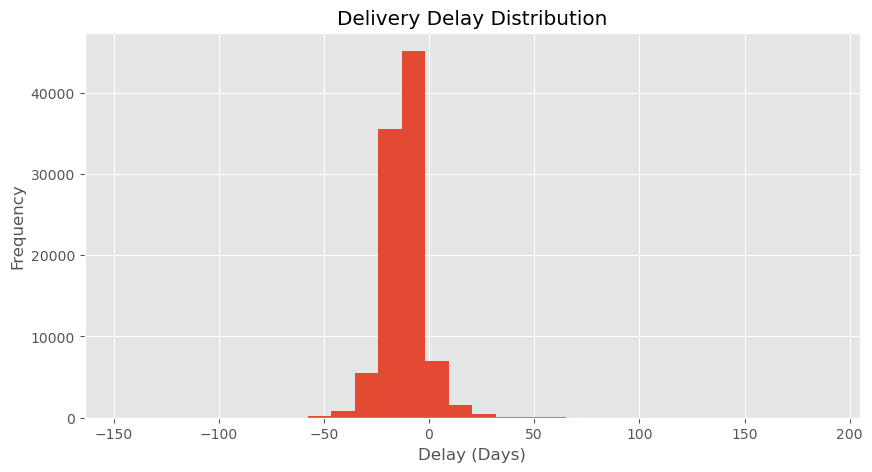

Late Delivery Rate: 0.06773722022371735


In [81]:
# Plot delivery delays
plt.figure(figsize=(10, 5))
plt.hist(orderdf['delivery_delay_days'].dropna(), bins=30)

plt.title('Delivery Delay Distribution')
plt.xlabel('Delay (Days)')
plt.ylabel('Frequency')

plt.show()

# Calculate percentage of late deliveries
delay_rate = (orderdf['delivery_delay_days'] > 0).mean()

print("Late Delivery Rate:", delay_rate)

#### Delivery Status Breakdown

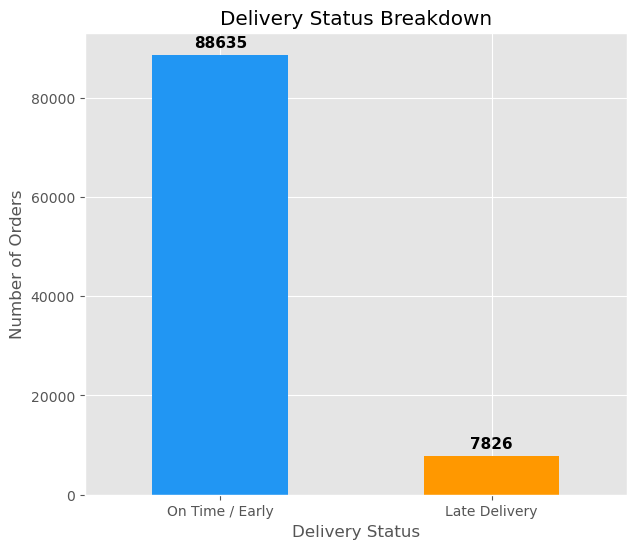

In [82]:
# Count delivery statuses (On-Time, Late, etc.)
delivery_status_counts = orderdf['delivery_status'].value_counts()

# Plot
plt.figure(figsize=(7,6))

ax = delivery_status_counts.plot(kind='bar', color=['#2196F3', '#FF9800'])

ax.bar_label(ax.containers[0], padding=3, fontsize=11, fontweight='bold')

plt.title('Delivery Status Breakdown')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')

plt.xticks(rotation=0)

plt.show()

#### Processing Time vs Delivery Delay (Root Cause)

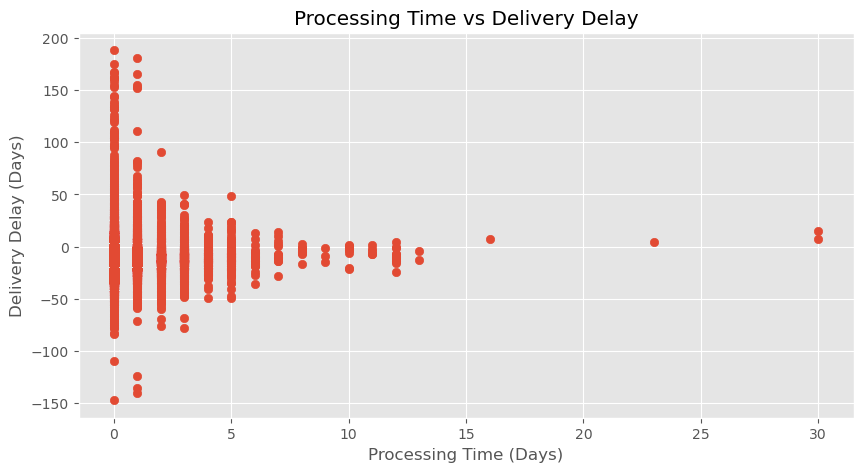

In [83]:
# Scatter plot to check relationship between processing time and delays
plt.figure(figsize=(10, 5))
plt.scatter(orderdf['processing_time'], orderdf['delivery_delay_days'])

plt.title('Processing Time vs Delivery Delay')
plt.xlabel('Processing Time (Days)')
plt.ylabel('Delivery Delay (Days)')

plt.show()

#### Seller to Carrier Time Impact On Delivery Delay

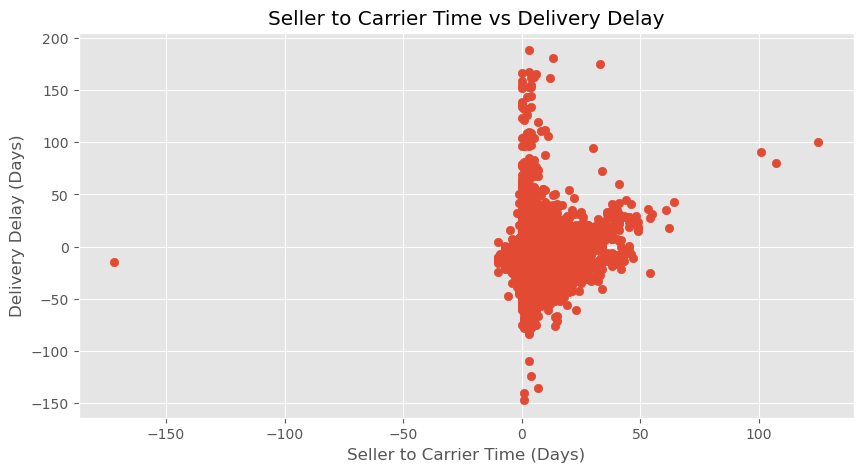

In [84]:
# Check if seller delays affect final delivery delay
plt.figure(figsize=(10, 5))
plt.scatter(orderdf['seller_to_carrier_days'], orderdf['delivery_delay_days'])

plt.title('Seller to Carrier Time vs Delivery Delay')
plt.xlabel('Seller to Carrier Time (Days)')
plt.ylabel('Delivery Delay (Days)')

plt.show()

#### Actual vs Estimated Delivery Difference Distribution

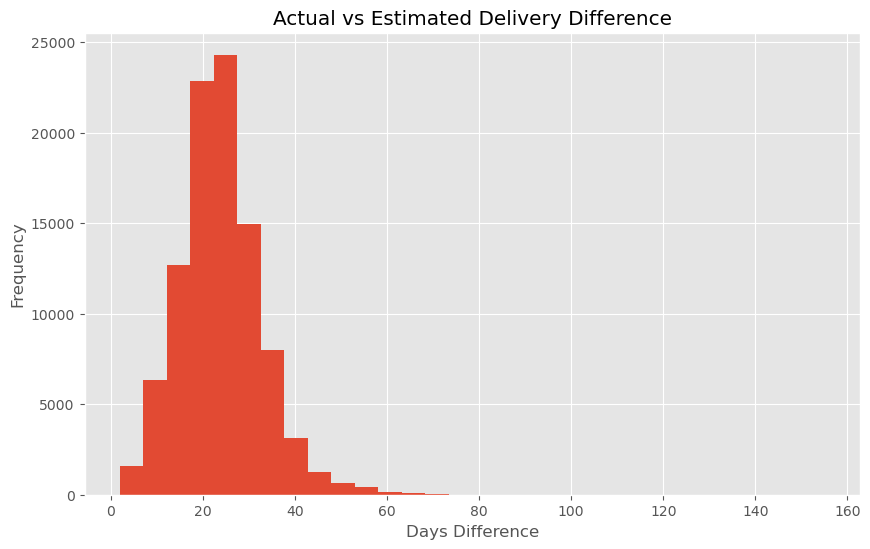

In [85]:
# Difference between actual delivery time and expected time
# (positive = late, negative = early)
delivery_diff = orderdf['delivery_days'] - orderdf['delivery_delay_days']

# Plot distribution
plt.figure(figsize=(10, 6))
plt.hist(delivery_diff.dropna(), bins=30)

plt.title('Actual vs Estimated Delivery Difference')
plt.xlabel('Days Difference')
plt.ylabel('Frequency')

plt.show()

#### Time Breakdown (Where is the delay?)

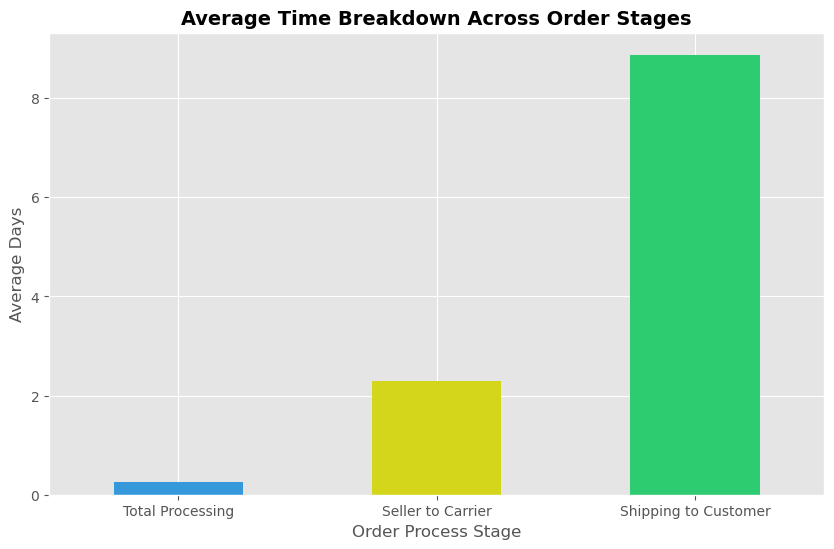

In [86]:
# Calculate average time spent in each stage
time_components = orderdf[['processing_time', 'seller_to_carrier_days', 'shipping_time']].mean()

# Create x axis labels list
clean_labels = ['Total Processing', 'Seller to Carrier', 'Shipping to Customer']

# Plot comparison
plt.figure(figsize=(10, 6))

# Assigning colors
bar_colors = ['#3498db', "#d3d61b", '#2ecc71']

# Plotting with the custom labels and colors
time_components.plot(kind='bar', color=bar_colors)

# Set x axis labels
plt.xticks(ticks=range(len(clean_labels)), labels=clean_labels, rotation=0)

# Titles and formatting
plt.title('Average Time Breakdown Across Order Stages', fontsize=14, fontweight='bold')
plt.xlabel('Order Process Stage', fontsize=12)
plt.ylabel('Average Days', fontsize=12)

plt.show()